In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from numpy.fft import fft
from matplotlib.gridspec import GridSpec

In [3]:
# ================================================================
# Detect the start and end of activity cycles (bursts)
# ================================================================
#
# This function identifies periods of elevated network activity
# (activity cycles) in the time series rho(t).
#
# The minimum value of rho is used as a baseline ("threshold").
# A time point is considered part of a burst when its activity
# exceeds this baseline by more than the specified precision.
#
# Parameters
# ----------
# Rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance above the minimum activity used to distinguish
#     active periods from silent periods.
#
# Returns
# -------
# startlocs : list
#     Time indices corresponding to the beginning of each
#     detected activity cycle.
#
# endlocs : list
#     Time indices corresponding to the end of each
#     detected activity cycle.
#
# Notes
# -----
# The function scans the activity time series and identifies a
# cycle when rho rises above the baseline threshold. The start
# point is shifted one time step backward when the activity is
# already increasing at the detected crossing.
#
# The final 10 time steps are excluded from the search to avoid
# detecting an incomplete cycle at the end of the simulation.
# ================================================================

def StartAndEndPoints(Rho, precision):

    # Time indices corresponding to the activity time series.
    t = np.arange(0, len(Rho))
    tmax = max(t)

    # Use the minimum observed activity as the baseline.
    threshold = min(Rho)

    # Flag indicating whether the algorithm is currently
    # inside an activity cycle.
    flag = False

    # Current position in the time series.
    i = 0

    # Lists containing the detected start and end times
    # of activity cycles.
    startlocs = []
    endlocs = []

    # Scan the time series, excluding the last 10 time steps.
    while i < (tmax - 10):

        # If the activity is still within 'precision' of the
        # baseline, no activity cycle has started yet.
        if Rho[i] - threshold <= precision:
            i = i + 1
            continue

        # The activity has risen above the baseline:
        # mark this point as the tentative beginning of a cycle.
        first = i

        # If the activity was already increasing between the
        # previous and current time step, move the start point
        # one step backward.
        if Rho[i - 1] < Rho[i]:
            first = first - 1

            # Preserve the original boundary condition for i = 0.
            if i == 0:
                first = 0

        # Store the detected start time.
        startlocs.append(first)

        # We are now inside an activity cycle.
        flag = True

        # Continue until the activity returns to the baseline
        # (within the specified precision).
        while flag and i < tmax - 1:

            i = i + 1

            # Once the activity falls back to the baseline region,
            # the current activity cycle is considered finished.
            if Rho[i] - threshold <= precision:
                flag = False

        # Store the detected end time.
        endlocs.append(i)

        # Move to the next time point before searching for
        # another activity cycle.
        i = i + 1

    return startlocs, endlocs

In [5]:
# ================================================================
# Calculate the duration of detected activity bursts
# ================================================================
#
# This function identifies activity cycles in rho(t) using
# StartAndEndPoints() and groups nearby activity cycles into
# individual bursts.
#
# Parameters
# ----------
# Rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance used by StartAndEndPoints() to distinguish
#     active periods from the baseline/silent state.
#
# Returns
# -------
# y_new : ndarray
#     Binary time series indicating burst activity:
#
#         1 -> time point belongs to a detected burst
#         0 -> time point is outside a detected burst
#
# Notes
# -----
# Two consecutive activity cycles are considered part of the
# same burst when the silent interval between them is shorter
# than smean.
#
# Internally, the duration of each detected burst is assigned
# to all of its time points. This representation is subsequently
# converted into a binary burst indicator.
# ================================================================

def BurstWidth(Rho, precision):

    # Length of the activity time series.
    tmax = len(Rho)

    # Store the duration of the burst associated with each
    # time point. Zero indicates that the point is not part
    # of a detected burst.
    y = np.zeros(tmax)

    # Binary output array.
    #
    # Initialize it here so that it is also defined in the
    # special case where the activity starts near t = 0.
    y_new = np.zeros(tmax)

    # Detect the start and end points of individual activity cycles.
    startlocs, endlocs = StartAndEndPoints(Rho, precision)

    # If no activity cycles are detected, return an array of zeros.
    if len(startlocs) == 0:
        return y_new

    # ------------------------------------------------------------
    # Group consecutive activity cycles into bursts.
    # ------------------------------------------------------------

    # Minimum silent interval required to separate two bursts.
    smean = 10

    # Start time of the current burst.
    a = startlocs[0]

    # Examine consecutive activity cycles.
    i = 0

    while i < len(endlocs):

        # If this is the last detected cycle, it defines the end
        # of the current burst.
        if i == len(endlocs) - 1:
            b = endlocs[i]

            # Duration of the current burst.
            burst_duration = b - a

            # Assign the burst duration to all time points
            # belonging to this burst.
            for j in np.arange(a, b):
                y[j] = burst_duration

            break

        # Check the silent interval before the next activity cycle.
        silent_interval = startlocs[i + 1] - endlocs[i]

        if silent_interval < smean:

            # The next activity cycle is close enough to the
            # current one to be considered part of the same burst.
            i += 1
            continue

        # The silent interval is long enough to separate the
        # current burst from the next one.
        b = endlocs[i]

        # Duration of the current burst.
        burst_duration = b - a

        # Assign the burst duration to all time points in the burst.
        for j in np.arange(a, b):
            y[j] = burst_duration

        # The next activity cycle starts a new burst.
        a = startlocs[i + 1]

        i += 1

    # ------------------------------------------------------------
    # Handle activity beginning very close to t = 0.
    # ------------------------------------------------------------

    if a < 10:

        # If the entire time series remains at a very low activity
        # level, classify it as having no detectable burst activity.
        if all(v < 0.01 for v in Rho):
            return y_new

        # Otherwise, classify the time series as continuously active.
        y_new[:] = 1

        # Exclude the first and last time points.
        y_new[0] = 0
        y_new[-1] = 0

        return y_new

    # ------------------------------------------------------------
    # Convert burst-duration representation into a binary indicator.
    # ------------------------------------------------------------

    # Any time point with a non-zero burst duration is marked as
    # belonging to a burst.
    y_new[y != 0] = 1

    return y_new

In [6]:
# ================================================================
# Extract burst onset times
# ================================================================
#
# This function converts the activity time series rho(t) into a
# binary burst signal and identifies the onset time of each burst.
#
# Parameters
# ----------
# rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance used by BurstWidth() and StartAndEndPoints()
#     to identify activity cycles.
#
# Returns
# -------
# burst_onsets : ndarray
#     Time indices at which a burst begins.
#
# Notes
# -----
# A burst onset is defined as a transition in the binary burst
# signal from:
#
#     0 -> 1
#
# Therefore, the returned time corresponds to the first time
# point at which the burst signal becomes active.
# ================================================================

def get_burst_onsets(rho, precision):

    # Convert rho(t) into a binary burst-activity signal.
    #
    #     0 -> outside a burst
    #     1 -> inside a burst
    burst = BurstWidth(rho, precision)

    # Detect transitions from 0 to 1.
    #
    # burst[:-1] contains the signal at times 0 ... tmax-2
    # burst[1:]  contains the signal at times 1 ... tmax-1
    #
    # Adding 1 converts the index of the preceding zero into
    # the actual time index at which the burst starts.
    burst_onsets = np.where(
        (burst[:-1] == 0) & (burst[1:] == 1)
    )[0] + 1

    return burst_onsets

In [7]:
# ================================================================
# Assign the first burst onset to each theta cycle
# ================================================================
#
# This function assigns at most one burst onset to each theta
# cycle. The assigned onset is the earliest burst onset occurring
# within the cycle.
#
# If a cycle contains no burst onset, a short lookback window
# immediately preceding the cycle is inspected. This allows a
# burst that starts just before a cycle boundary to be associated
# with the following theta cycle.
#
# Parameters
# ----------
# burst_onsets : array-like
#     Time indices of detected burst onsets.
#
# n_cycles : int
#     Number of theta cycles to analyze.
#
# T_theta : int, default=200
#     Duration of one theta cycle in simulation time steps (ms).
#
# lookback : int, default=25
#     Length of the time window immediately preceding a theta cycle
#     that is inspected when no burst onset occurs inside that
#     cycle.
#
# Returns
# -------
# first_bursts : ndarray
#     Array of length n_cycles.
#
#     Each element contains the time of the burst onset assigned
#     to that theta cycle. If no onset can be assigned, the value
#     is np.nan.
#
# Assignment rules
# ---------------
# 1. If one or more burst onsets occur within a theta cycle,
#    assign the earliest onset.
#
# 2. If no onset occurs within the cycle, inspect the preceding
#    `lookback` time steps.
#
# 3. If the latest onset in the lookback window is the same onset
#    that was already assigned to the previous cycle, do not
#    assign it again.
#
# 4. If the onset is a distinct, later onset, assign it to the
#    current cycle.
#
# This procedure prevents a single burst onset near a theta-cycle
# boundary from being counted in two consecutive cycles.
# ================================================================

def assign_first_bursts_to_cycles(
        burst_onsets,
        n_cycles,
        T_theta=200,
        lookback=25):

    # Initialize the output array.
    #
    # np.nan indicates that no burst onset could be assigned
    # to the corresponding theta cycle.
    first_bursts = np.full(n_cycles, np.nan)

    # Keep track of the burst onset assigned to the previous
    # theta cycle. This is used to prevent the same onset from
    # being assigned to two consecutive cycles.
    previous_assigned_onset = None

    # ------------------------------------------------------------
    # Process each theta cycle independently.
    # ------------------------------------------------------------

    for cycle in range(n_cycles):

        # Start and end times of the current theta cycle.
        #
        # Cycle 0:       [0, T_theta)
        # Cycle 1:       [T_theta, 2*T_theta)
        # etc.
        cycle_start = cycle * T_theta
        cycle_end = min(
            (cycle + 1) * T_theta,
            n_cycles * T_theta
        )

        # ========================================================
        # 1. Search for burst onsets inside the current cycle
        # ========================================================

        onsets_in_cycle = burst_onsets[
            (burst_onsets >= cycle_start) &
            (burst_onsets < cycle_end)
        ]

        if len(onsets_in_cycle) > 0:

            # If several bursts occur within the cycle, assign
            # the earliest one.
            first_onset = onsets_in_cycle[0]

            first_bursts[cycle] = first_onset

            # Remember this onset when processing the next cycle.
            previous_assigned_onset = first_onset

        # ========================================================
        # 2. No onset inside the current cycle:
        #    inspect the preceding lookback window
        # ========================================================

        else:

            # Beginning of the lookback window.
            #
            # max(0, ...) prevents the window from extending
            # before the beginning of the time series.
            lookback_start = max(
                0,
                cycle_start - lookback
            )

            # Find burst onsets occurring within the lookback
            # window but before the current theta cycle.
            previous_onsets = burst_onsets[
                (burst_onsets >= lookback_start) &
                (burst_onsets < cycle_start)
            ]

            if len(previous_onsets) > 0:

                # Use the latest onset in the lookback window.
                candidate = previous_onsets[-1]

                # ------------------------------------------------
                # Prevent double counting across cycle boundaries.
                # ------------------------------------------------
                #
                # If this onset was already assigned to the
                # previous cycle, it must not be assigned again.
                #
                # Otherwise, it represents a distinct later burst
                # and can be associated with the current cycle.
                if (previous_assigned_onset is None or
                        candidate != previous_assigned_onset):

                    first_bursts[cycle] = candidate

                    # Update the onset assigned to the previous
                    # cycle for subsequent comparisons.
                    previous_assigned_onset = candidate

                else:

                    # The candidate is the same onset that was
                    # already assigned to the previous cycle.
                    # Leave this cycle unassigned.
                    first_bursts[cycle] = np.nan

            else:

                # No burst onset was found either inside the cycle
                # or within the preceding lookback window.
                first_bursts[cycle] = np.nan

    return first_bursts

In [8]:
# ================================================================
# Construct the first-burst matrix for theta cycles
# ================================================================
#
# This function combines the burst-detection and theta-cycle
# assignment steps to construct a matrix containing the first
# burst onset associated with each theta cycle.
#
# Parameters
# ----------
# rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance used to detect activity bursts.
#
# T_theta : int, default=200
#     Duration of one theta cycle in simulation time steps (ms).
#
# lookback : int, default=25
#     Length of the lookback window used when a theta cycle does
#     not contain a burst onset.
#
# Returns
# -------
# result : ndarray
#     Two-column array with one row per theta cycle:
#
#         column 0 -> theta-cycle number
#         column 1 -> first burst onset time (t_fb)
#
#     If no burst can be assigned to a cycle, t_fb is np.nan.
#
# Processing steps
# ----------------
# 1. Determine the number of theta cycles represented by rho(t).
# 2. Detect burst onset times from rho(t).
# 3. Assign at most one first burst onset to each theta cycle.
# 4. Combine the cycle numbers and assigned onset times into
#    the output matrix.
# ================================================================

def FirstBurstMatrix(
        rho,
        precision,
        T_theta=200,
        lookback=25):

    # ------------------------------------------------------------
    # Determine the number of theta cycles.
    # ------------------------------------------------------------
    #
    # np.ceil() ensures that a partially represented final cycle
    # is also included.
    n_cycles = int(np.ceil(len(rho) / T_theta))

    # ------------------------------------------------------------
    # Detect burst onset times from the network activity.
    # ------------------------------------------------------------
    burst_onsets = get_burst_onsets(
        rho,
        precision
    )

    # ------------------------------------------------------------
    # Assign the first burst onset to each theta cycle.
    # ------------------------------------------------------------
    t_fb = assign_first_bursts_to_cycles(
        burst_onsets,
        n_cycles,
        T_theta=T_theta,
        lookback=lookback
    )

    # ------------------------------------------------------------
    # Construct the output matrix.
    # ------------------------------------------------------------
    #
    # Column 0: theta-cycle number
    # Column 1: first burst onset time
    cycle_numbers = np.arange(n_cycles)

    result = np.column_stack([
        cycle_numbers,
        t_fb
    ])

    return result

In [9]:
# ================================================================
# Calculate the one-sided power spectrum of network activity
# ================================================================
#
# This function calculates the frequency spectrum of the network
# activity time series rho(t) using the Fast Fourier Transform
# (FFT).
#
# Parameters
# ----------
# rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# Returns
# -------
# frequency : ndarray
#     Positive frequencies corresponding to the spectrum.
#
# power : ndarray
#     One-sided amplitude spectrum of rho(t).
#
# Notes
# -----
# The sampling frequency is set to 1 sample per simulation time
# step. Therefore, the resulting frequency is expressed in
# cycles per simulation time step.
#
# The DC component (zero frequency) is excluded from the returned
# spectrum. The spectrum is converted to a one-sided representation
# by multiplying the non-boundary positive-frequency components
# by two.
#
# ================================================================

def PS(rho):

    from numpy.fft import fft

    # Number of samples in the activity time series.
    L = len(rho)

    # ------------------------------------------------------------
    # Compute the discrete Fourier transform.
    # ------------------------------------------------------------
    Y = fft(rho)

    # Two-sided amplitude spectrum, normalized by the number
    # of samples.
    P2 = np.abs(Y / L)

    # Keep the non-negative frequencies to construct the
    # one-sided spectrum.
    P1 = P2[0:int(L / 2) + 1]

    # Double the amplitude of the non-boundary positive-frequency
    # components because the negative-frequency components are
    # omitted from the one-sided spectrum.
    end = len(P1) - 1
    P1[1:end] = 2 * P1[1:end]

    # Frequency indices.
    x = np.arange(0, int(L / 2) + 1)

    # Sampling frequency: one sample per simulation time step.
    Fs = 1

    # Convert frequency indices to physical frequencies.
    f = Fs * x / L

    # Exclude the zero-frequency (DC) component.
    #
    # The upper two entries are also excluded, as in the original
    # analysis code.
    frequency = f[1:-2]
    power = P1[1:-2]

    return frequency, power

In [10]:
def PAC(rho):
    """
    Calculate phase-amplitude coupling (PAC) between theta phase
    and gamma amplitude.

    Parameters
    ----------
    rho : array-like
        Time series of network activity.

    Returns
    -------
    Vlo : ndarray
        Band-pass filtered low-frequency signal (theta).
    Vhi : ndarray
        Band-pass filtered high-frequency signal (gamma).
    a_mean : ndarray
        Mean gamma amplitude within each theta-phase bin.
    p_mean : ndarray
        Center phase of each phase bin.
    PAC_value : float
        PAC quantified using the Mean Vector Length (MVL) measure.

    Notes
    -----
    The simulation time step is 1 ms, so with fs=1 sample/ms,
    frequencies are expressed in cycles/ms. For example,
    0.005 cycles/ms corresponds to 5 Hz.
    """

    from scipy import signal

    # Sampling frequency: 1 sample per ms
    fs = 1

    # Number of taps in the FIR filters
    n = 505

    # --------------------------------------------------
    # Low-frequency component (theta)
    # --------------------------------------------------
    theta_low = 0.003
    theta_high = 0.008

    theta_filter = signal.firwin(
        n,
        [theta_low, theta_high],
        pass_zero=False,
        fs=fs
    )

    Vlo = signal.filtfilt(theta_filter, 1, rho)

    # --------------------------------------------------
    # High-frequency component (gamma)
    # --------------------------------------------------
    gamma_low = 0.06
    gamma_high = 0.09

    gamma_filter = signal.firwin(
        n,
        [gamma_low, gamma_high],
        pass_zero=False,
        fs=fs
    )

    Vhi = signal.filtfilt(gamma_filter, 1, rho)

    # --------------------------------------------------
    # Instantaneous gamma amplitude
    # and theta phase
    # --------------------------------------------------
    gamma_analytic = signal.hilbert(Vhi)
    theta_analytic = signal.hilbert(Vlo)

    amp = np.abs(gamma_analytic)
    phi = np.angle(theta_analytic)

    # --------------------------------------------------
    # Phase-amplitude coupling
    #
    # Mean Vector Length:
    #   PAC = | mean( A(t) * exp(i*phi(t)) ) |
    # --------------------------------------------------
    PAC_value = np.abs(
        np.mean(amp * np.exp(1j * phi))
    )

    # --------------------------------------------------
    # Mean gamma amplitude as a function of theta phase
    # --------------------------------------------------
    p_bins = np.arange(-np.pi, np.pi, 0.1)

    a_mean = np.zeros(len(p_bins) - 1)
    p_mean = np.zeros(len(p_bins) - 1)

    for k in range(len(p_bins) - 1):
        # Phase-bin boundaries
        pL = p_bins[k]
        pR = p_bins[k + 1]

        # Select samples whose theta phase falls
        # within the current phase bin
        indices = (phi >= pL) & (phi < pR)

        # Mean gamma amplitude in this phase bin
        if np.any(indices):
            a_mean[k] = np.mean(amp[indices])

        # Center of the phase bin
        p_mean[k] = (pL + pR) / 2

    return Vlo, Vhi, a_mean, p_mean, PAC_value

In [11]:
# ==========================================================
# Load simulation data
# ==========================================================

data = np.loadtxt("ActivityInTime.txt")
eta_time = np.loadtxt("EtaInTime.txt")
data_params = np.loadtxt("Parameters.txt")

# Time series
time = data[:, 0]
rho = data[:, 1]

# External input
eta = eta_time[:, 1]


# ==========================================================
# Load model parameters
# ==========================================================

W_E = data_params[0]
W_I = data_params[1]
T_E = data_params[2]
T_I = data_params[3]
D = data_params[4]
eta_0 = data_params[5]
eta_A = data_params[6]
T_theta = data_params[7]


# ==========================================================
# Parameter string used in figure titles
# ==========================================================

title_text_1 = (
    r"$W_E=$" + str(int(W_E)) + " , "
    + r"$W_I=$" + str(int(W_I)) + " , "
)

title_text_2 = (
    r"$\delta_E=$" + str(int(T_E)) + " , "
    + r"$\delta_I=$" + str(int(T_I)) + "\n\n"
)

title_text_3 = (
    r"$D=$" + str(D) + " , "
    + r"$T^{\theta}=$" + str(int(T_theta)) + " , "
)

title_text_4 = (
    r"$\eta_0=$" + str(eta_0) + " , "
    + r"$\eta_A=$" + str(eta_A)
)

title_text = (
    title_text_1
    + title_text_2
    + title_text_3
    + title_text_4
)


# ==========================================================
# Burst-detection parameters
# ==========================================================

precision = 0.02
lookback = 25


# ==========================================================
# Theta phase
#
# The phase is calculated from the position within each
# theta cycle. With T_theta in ms, phi_values ranges from
# 0 to 2*pi over one theta cycle.
# ==========================================================

phi_values = (
    2 * np.pi * (time % T_theta) / T_theta
)


# ==========================================================
# First burst in each theta cycle
# ==========================================================

result = FirstBurstMatrix(
    rho,
    precision,
    T_theta=T_theta,
    lookback=lookback
)

# Column 1 contains the first-burst onset time (t_fb)
first_starts = result[:, 1]

# Remove theta cycles for which no burst was detected
first_starts = first_starts[~np.isnan(first_starts)].astype(int)


# Convert first-burst onset times to theta phases
first_phis = (
    2 * np.pi * (first_starts % T_theta) / float(T_theta)
)


# ==========================================================
# Circular statistics of first-burst phases
# ==========================================================

N_first_bursts = len(first_phis)

if N_first_bursts > 0:

    # Mean unit vector of the burst-onset phases
    mean_vector = np.mean(np.exp(1j * first_phis))

    # Resultant vector length: concentration of phases
    R = np.abs(mean_vector)

    # Preferred phase (circular mean)
    phi_pref = np.angle(mean_vector)

    # Express phase in the range [0, 2*pi)
    if phi_pref < 0:
        phi_pref += 2 * np.pi

else:
    R = np.nan
    phi_pref = np.nan
    print("No bursts detected.")


# ==========================================================
# Phase-amplitude coupling (PAC)
# ==========================================================

Vlo, Vhi, a_mean, p_mean, PAC_value = PAC(rho)


# ==========================================================
# Power spectrum
# ==========================================================

frequency, power = PS(rho)

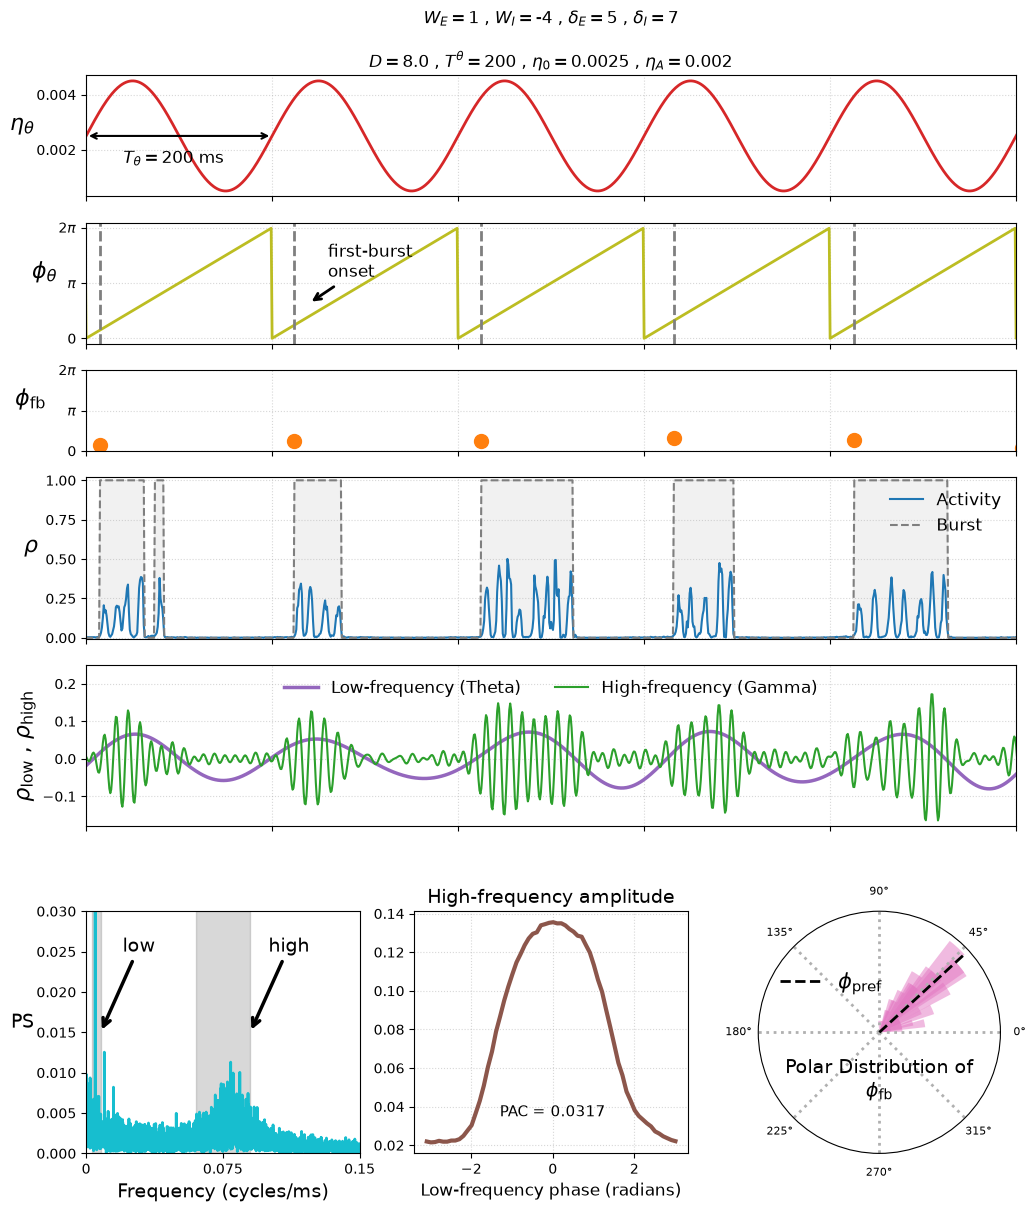

In [12]:
# ==========================================================
# Figure formatting parameters
# ==========================================================

font_size = 14
marker_size = 10
line_width = 2


# Time window shown in panels A-E
t_left, t_right = 14000, 15000


# ==========================================================
# Create figure and layout
# ==========================================================

fig = plt.figure(figsize=(12, 14))

gs = GridSpec(
    7,
    3,
    height_ratios=[0.75, 0.75, 0.5, 1, 1, 0.2, 1.5]
)


# ==========================================================
# A — Theta-modulated external input
# ==========================================================

ax = fig.add_subplot(gs[0, :])

ax.plot(
    eta,
    color="C3",
    lw=line_width
)

ax.set_ylabel(
    r"$\eta_\theta$",
    fontsize=font_size + 2,
    rotation=0,
    labelpad=10
)

ax.grid(linestyle=":", alpha=0.5)
ax.set_xlim(t_left, t_right)
ax.set_xticklabels([])

# Indicate one theta cycle
ax.annotate(
    "",
    xy=(t_left, 0.0025),
    xytext=(t_left + 200, 0.0025),
    arrowprops=dict(
        arrowstyle="<->",
        lw=line_width - 0.5,
        color="black"
    )
)

ax.text(
    t_left + 40,
    0.0015,
    r"$T_\theta = 200$ ms",
    fontsize=font_size - 2
)

ax.set_title(
    title_text,
    fontsize=font_size - 2
)


# ==========================================================
# B — Theta phase and burst onsets
# ==========================================================

ax = fig.add_subplot(gs[1, :])

ax.plot(
    time,
    phi_values,
    color="C8",
    lw=line_width
)

ax.grid(linestyle=":", alpha=0.5)
ax.set_xlim(t_left, t_right)

ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

ax.set_ylabel(
    r"$\phi_\theta$",
    fontsize=font_size + 2,
    rotation=0,
    labelpad=10
)

ax.set_xticklabels([])

# Mark burst-onset times
for burst_onset in first_starts:
    ax.axvline(
        burst_onset,
        color="C7",
        linestyle="--",
        linewidth=line_width
    )

# Add annotation only when at least one burst was detected
if N_first_bursts > 0:
    ax.annotate(
        "first-burst\nonset",
        xy=(t_left + 240, 2),
        xytext=(t_left + 260, 3.5),
        fontsize=font_size - 2,
        arrowprops=dict(
            arrowstyle="->",
            facecolor="lightgray",
            lw=line_width
        )
    )


# ==========================================================
# C — Phase of first burst in each theta cycle
# ==========================================================

ax = fig.add_subplot(gs[2, :])

if N_first_bursts > 0:
    ax.plot(
        first_starts,
        first_phis,
        "o",
        ms=marker_size,
        color="C1"
    )

ax.grid(linestyle=":", alpha=0.5)
ax.set_xlim(t_left, t_right)

ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

ax.set_ylabel(
    r"$\phi_{\mathrm{fb}}$",
    fontsize=font_size + 2,
    rotation=0,
    labelpad=20
)

ax.set_xticklabels([])


# ==========================================================
# D — Network activity and detected bursts
# ==========================================================

ax = fig.add_subplot(gs[3, :])

ax.plot(
    time,
    rho,
    color="C0",
    lw=line_width - 0.5,
    label="Activity"
)

# Binary burst indicator
burst_signal = BurstWidth(
    rho,
    precision
)

ax.plot(
    time,
    burst_signal,
    "--",
    color="C7",
    label="Burst",
    lw=line_width - 0.5
)

ax.grid(linestyle=":", alpha=0.5)
ax.set_xlim(t_left, t_right)
ax.set_ylim(-0.005, 1.02)

ax.set_ylabel(
    r"$\rho$",
    fontsize=font_size + 2,
    rotation=0,
    labelpad=10
)

ax.set_xticklabels([])

# Highlight the detected burst regions
ax.fill_between(
    time,
    rho,
    burst_signal,
    alpha=0.1,
    color="C7"
)

ax.legend(
    ncol=1,
    fontsize=font_size - 2,
    frameon=False,
    loc="upper right"
)


# ==========================================================
# E — Low- and high-frequency components
# ==========================================================

ax = fig.add_subplot(gs[4, :])

ax.plot(
    time,
    Vlo,
    lw=line_width + 0.5,
    label="Low-frequency (Theta)",
    color="C4"
)

ax.plot(
    time,
    Vhi,
    lw=line_width - 0.5,
    label="High-frequency (Gamma)",
    color="C2"
)

ax.grid(linestyle=":", alpha=0.5)
ax.set_xlim(t_left, t_right)

ax.set_ylabel(
    r"$\rho_{\mathrm{low}}$ , $\rho_{\mathrm{high}}$",
    fontsize=font_size + 2
)

ax.set_xticklabels([])

ax.set_ylim(-0.18, 0.25)

ax.legend(
    ncol=2,
    fontsize=font_size - 2,
    frameon=False,
    loc="upper center"
)


# ==========================================================
# F — Power spectrum
# ==========================================================

ax = fig.add_subplot(gs[6, 0])

# Highlight the frequency bands used for PAC
ax.axvspan(
    0.003,
    0.008,
    alpha=0.3,
    color="C7"
)

ax.axvspan(
    0.06,
    0.09,
    alpha=0.3,
    color="C7"
)

ax.plot(
    frequency,
    power,
    color="C9",
    lw=line_width
)

ax.set_xlabel(
    "Frequency (cycles/ms)",
    fontsize=font_size
)

ax.set_ylabel(
    "PS",
    fontsize=font_size,
    rotation=0,
    labelpad=10
)

ax.set_xlim(0, 0.15)
ax.set_ylim(0, 0.03)

ax.set_xticks([0, 0.075, 0.15])
ax.set_xticklabels(
    [0, 0.075, 0.15],
    fontsize=font_size - 4
)

# Indicate the low- and high-frequency bands
ax.annotate(
    "low",
    xy=(0.008, 0.015),
    xytext=(0.02, 0.025),
    fontsize=font_size,
    arrowprops=dict(
        arrowstyle="->",
        facecolor="lightgray",
        lw=line_width + 0.5
    )
)

ax.annotate(
    "high",
    xy=(0.09, 0.015),
    xytext=(0.1, 0.025),
    fontsize=font_size,
    arrowprops=dict(
        arrowstyle="->",
        facecolor="lightgray",
        lw=line_width + 0.5
    )
)


# ==========================================================
# G — Phase-amplitude coupling
# ==========================================================

ax = fig.add_subplot(gs[6, 1])

ax.plot(
    p_mean,
    a_mean,
    color="C5",
    lw=line_width + 1,
    label="High-frequency\namplitude"
)

ax.set_xlabel(
    "Low-frequency phase (radians)",
    fontsize=font_size - 2
)

ax.grid(linestyle=":", alpha=0.5)

ax.set_title(
    "High-frequency amplitude",
    fontsize=font_size
)

ax.text(
    -1.3,
    0.035,
    "PAC = " + str(np.round(PAC_value, 4)),
    fontsize=font_size - 3
)


# ==========================================================
# H — Polar distribution of first-burst phases
# ==========================================================

ax = fig.add_subplot(
    gs[6, 2],
    projection="polar"
)

if N_first_bursts > 0:

    # Histogram of first-burst phases
    n, bins = np.histogram(
        first_phis,
        bins=36
    )

    theta = (bins[:-1] + bins[1:]) / 2
    width = 2 * np.pi / len(n)

    ax.bar(
        theta,
        n / N_first_bursts,
        width=width,
        alpha=0.5,
        color="C6"
    )

    # Preferred phase
    ax.plot(
        [phi_pref, phi_pref],
        [0, max(n / N_first_bursts)],
        color="k",
        linestyle="--",
        linewidth=line_width,
        label=r"$\phi_{\mathrm{pref}}$"
    )

ax.set_title(
    "Polar Distribution of\n" + r"$\phi_{\mathrm{fb}}$",
    x=0.5,
    y=0.2,
    fontsize=font_size
)

# Polar grid
ax.xaxis.grid(
    True,
    linestyle=":",
    linewidth=line_width,
    alpha=1
)

ax.yaxis.grid(
    True,
    linestyle=":",
    linewidth=0.8,
    alpha=1
)

ax.tick_params(
    axis="x",
    labelsize=font_size - 6
)

ax.tick_params(
    axis="y",
    labelsize=font_size - 4
)

# Hide radial tick labels
ax.set_yticks([])

if N_first_bursts > 0:
    ax.legend(
        frameon=False,
        loc="center",
        bbox_to_anchor=(0.3, 0.7),
        fontsize=font_size + 1
    )